In [653]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import *
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

data = pd.read_csv('../datasets/mood_detection_data_realistic.csv')


## Analyse dataset data
Let’s analyse the data contained in the dataset:
| Feature Name | Description | Value |
|---|---|---|
| Speech Duration | Total duration of the analysed sample | seconds |
| Pitch | Voice frequency | Hz |
| Speech Rate | The speed at which the speaker speaks | Words Per Minute (WPM) |
| Jitter | Variation in frequency during pitch | % |
| Shimmer | Similar to jitter, but calculates the variation in voice volume intensity | % |
| MFCCs | Describe the short-term power spectrum of the sound | Dimensionless coefficients |
| Mood | The speaker’s emotional state | E.g: Sad, Neutral... |
| Sentiment Score | A score indicating the positivity or negativity of the speech | Values ranging from -1 to 1 |
| Speaker ID | A unique identifier for the speaker | Alphanumerics values |
| Age Group | The speaker’s age group | E.g: Child, Senior...|
| Gender | The speaker’s gender | Male/Female |
| Language | The speaker’s language| English |

In [654]:
display(data.head())
data.info()

,Speech Duration,Pitch,Speech Rate,Jitter,Shimmer,MFCCs,Mood,Sentiment Score,Speaker ID,Age Group,Gender,Language
0,18.02,138.88,77,0.018,0.020,"[2.508, -0.059, -4.787, -3.823, 7.839, 4.188, ...",Sad,-0.29,d969902b-9016-4fbe-912c-657c64094e6e,Child,Male,English
1,3.66,284.85,165,0.036,0.046,"[7.142, 7.646, 0.855, 5.951, -0.062, 3.756, 4....",Surprised,0.46,188e3a5c-21be-45ce-a35e-68fc8809b099,Senior,Male,English
2,8.93,179.56,117,0.027,0.083,"[3.557, -5.489, 0.748, 0.675, 9.397, -6.319, 4...",Neutral,0.00,7e9b7dfc-2437-405a-9bbb-20d150676e29,Senior,Female,English
3,12.41,218.57,132,0.053,0.038,"[9.45, -6.478, -7.879, -6.744, 3.796, -7.392, ...",Fearful,-0.37,8c28d2c1-1bbf-49e1-9c2a-eaf132279035,Child,Male,English
4,12.32,153.69,63,0.015,0.033,"[-0.875, 5.894, -8.461, 6.59, -7.81, -0.885, -...",Bored,-0.18,43a54995-e8f3-4a65-9b8c-e3cd23c85396,Senior,Female,English


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Speech Duration  10000 non-null  float64
 1   Pitch            10000 non-null  float64
 2   Speech Rate      10000 non-null  int64  
 3   Jitter           10000 non-null  float64
 4   Shimmer          10000 non-null  float64
 5   MFCCs            10000 non-null  str    
 6   Mood             10000 non-null  str    
 7   Sentiment Score  10000 non-null  float64
 8   Speaker ID       10000 non-null  str    
 9   Age Group        10000 non-null  str    
 10  Gender           10000 non-null  str    
 11  Language         10000 non-null  str    
dtypes: float64(5), int64(1), str(6)
memory usage: 2.4 MB


### Missing Values  and Unique Data Types
Analysis of the dataset to check for missing data within the features and to examine the unique values within them.

In [655]:
print("Missing Values:\n", data.isnull().sum())
print("\nDuplicate Rows:", data.duplicated().sum())
print("\nUnique Moods:", data['Mood'].unique())
print("\nUnique Genders:", data['Gender'].unique())
print("\nUnique Age Groups:", data['Age Group'].unique())
print("\nUnique Languages:", data['Language'].unique())

Missing Values:
 Speech Duration    0
Pitch              0
Speech Rate        0
Jitter             0
Shimmer            0
MFCCs              0
Mood               0
Sentiment Score    0
Speaker ID         0
Age Group          0
Gender             0
Language           0
dtype: int64

Duplicate Rows: 0

Unique Moods: <ArrowStringArray>
[      'Sad', 'Surprised',   'Neutral',   'Fearful',     'Bored',     'Happy',
     'Angry',   'Excited',  'Confused',      'Calm']
Length: 10, dtype: str

Unique Genders: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

Unique Age Groups: <ArrowStringArray>
['Child', 'Senior', 'Adult']
Length: 3, dtype: str

Unique Languages: <ArrowStringArray>
['English']
Length: 1, dtype: str


### Feature manipulation
I moved the ‘Mood’ feature to the end of the dataset because I found it useful for analysing the results.
I also decided to remove the ‘Speaker ID’ and 'Language' features because they are unnecessary or constant for training our model.

**MFCCs Parsing & Categorical Encoding**:
The `MFCCs` feature is currently a string representing an array. To make it usable by ML algorithms, we need to parse it and expand it into 13 separate numerical features. We also encode `Gender` and `Age Group`.

In [656]:
# Drop non-predictive or constant columns
data.drop(columns=['Speaker ID', 'Language', 'Sentiment Score'], inplace=True, errors='ignore')

if data['Gender'].dtype != int:
    data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

if data['Age Group'].dtype != int:
    data['Age Group'] = data['Age Group'].map({'Child': 0, 'Adult': 1, 'Senior': 2})

# Parse and expand MFCCs
if 'MFCCs' in data.columns:
    mfcc_lists = data['MFCCs'].apply(ast.literal_eval)
    mfcc_df = pd.DataFrame(mfcc_lists.tolist(), index=data.index)
    mfcc_df.columns = [f'MFCC_{i}' for i in range(mfcc_df.shape[1])]
    
    # Concat the new columns and drop the old string column
    data = pd.concat([data, mfcc_df], axis=1)
    data.drop(columns=['MFCCs'], inplace=True)
    # Drop previous incorrect parsed attempts if present
    data.drop(columns=['MFCC_mean', 'MFCC_std', 'mfcc_list'], inplace=True, errors='ignore')

# Move 'Mood' to the end
if 'Mood' in data.columns:
    mood_col = data.pop('Mood')
    data['Mood'] = mood_col

print("Final Data Structure after Feature Manipulation:")
data.info()
data.head()

Final Data Structure after Feature Manipulation:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Speech Duration  10000 non-null  float64
 1   Pitch            10000 non-null  float64
 2   Speech Rate      10000 non-null  int64  
 3   Jitter           10000 non-null  float64
 4   Shimmer          10000 non-null  float64
 5   Age Group        10000 non-null  int64  
 6   Gender           10000 non-null  int64  
 7   MFCC_0           10000 non-null  float64
 8   MFCC_1           10000 non-null  float64
 9   MFCC_2           10000 non-null  float64
 10  MFCC_3           10000 non-null  float64
 11  MFCC_4           10000 non-null  float64
 12  MFCC_5           10000 non-null  float64
 13  MFCC_6           10000 non-null  float64
 14  MFCC_7           10000 non-null  float64
 15  MFCC_8           10000 non-null  float64
 16  MFCC_9           1000

,Speech Duration,Pitch,Speech Rate,Jitter,Shimmer,Age Group,Gender,MFCC_0,MFCC_1,MFCC_2,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,Mood
0,18.02,138.88,77,0.018,0.020,0,0,2.508,-0.059,-4.787,...,7.839,4.188,8.894,9.261,-0.760,-0.398,3.277,-5.017,3.091,Sad
1,3.66,284.85,165,0.036,0.046,2,0,7.142,7.646,0.855,...,-0.062,3.756,4.685,-7.596,1.799,6.538,6.835,-6.795,-6.850,Surprised
2,8.93,179.56,117,0.027,0.083,2,1,3.557,-5.489,0.748,...,9.397,-6.319,4.925,4.346,-7.538,-8.083,7.187,4.724,-8.419,Neutral
3,12.41,218.57,132,0.053,0.038,0,0,9.450,-6.478,-7.879,...,3.796,-7.392,-7.476,-9.396,-8.825,1.587,2.440,9.947,3.216,Fearful
4,12.32,153.69,63,0.015,0.033,2,1,-0.875,5.894,-8.461,...,-7.810,-0.885,-0.831,-7.023,-3.096,-4.936,0.492,2.467,-0.431,Bored


## Mood Plot
To see if the mood class was balanced, I plotted the feature using a bar chart. As you can see, the classes are well balanced.

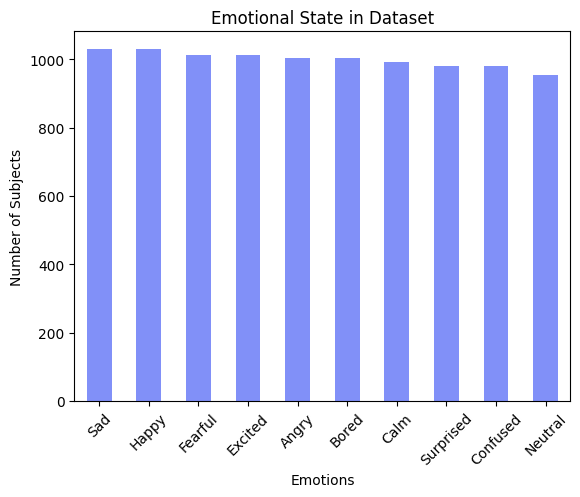

In [657]:
counts=data['Mood'].value_counts()
counts.plot(kind='bar', color='#8190f8')
plt.title('Emotional State in Dataset')
plt.xlabel('Emotions')
plt.xticks(rotation=45)
plt.ylabel('Number of Subjects')
plt.show()


## Univariate Distribution
Analysis of the distribution of numerical data in relation to the ‘Mood’ feature. These were the most significant and influential features for ‘Mood’. The results were indeed consistent with my expectations.

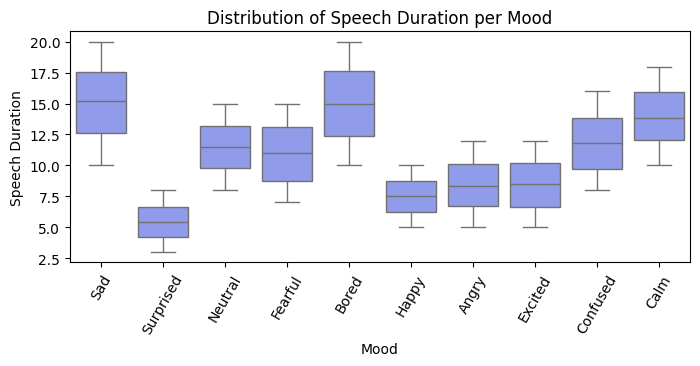

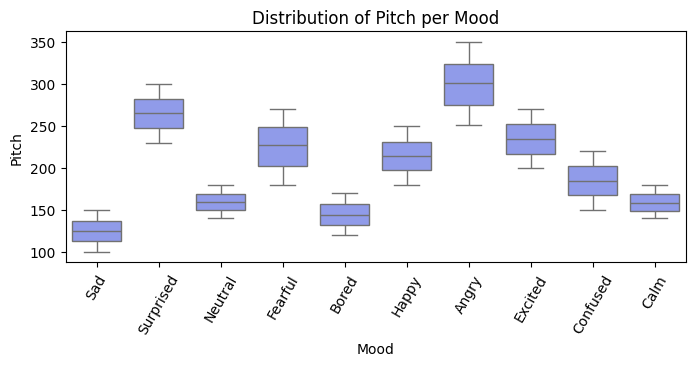

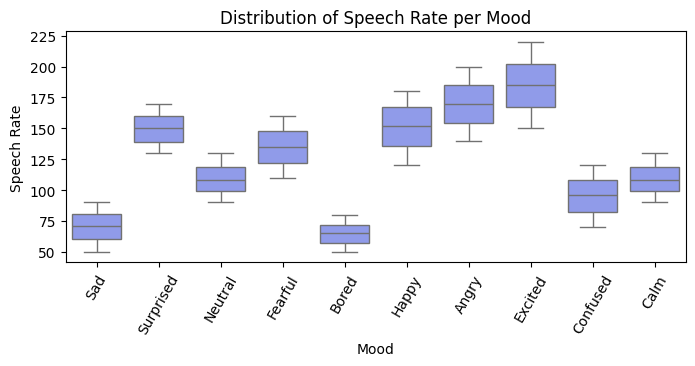

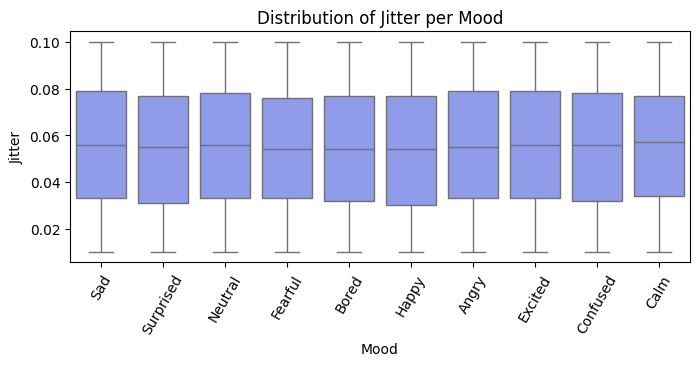

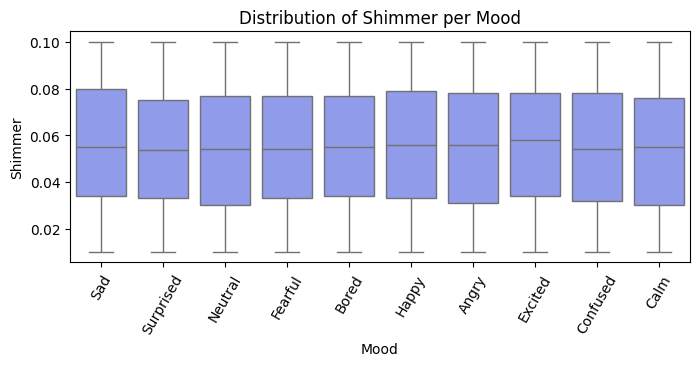

In [658]:
plot_cols = [c for c in data.select_dtypes(include=['number']).columns.tolist()
             if not c.startswith('MFCC_') and c not in ('Gender', 'Age Group')]

for col in plot_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(data=data, x='Mood', y=col, color='#8190f8')
    plt.xticks(rotation=60)
    plt.title(f'Distribution of {col} per Mood')
    plt.show()

## Feature relationships and outliers

Before modelling we inspect how the numeric features relate to each other and whether they
contain anomalous values.

- **Correlation matrix**: highlights redundant features;
- **Outlier detection**: the features are standardized (zero mean, unit variance) so they
  share the same scale and can be compared in a single boxplot.

`Gender` and `Age Group` are excluded here: they are categorical codes, so correlation and
boxplots on them are not meaningful.

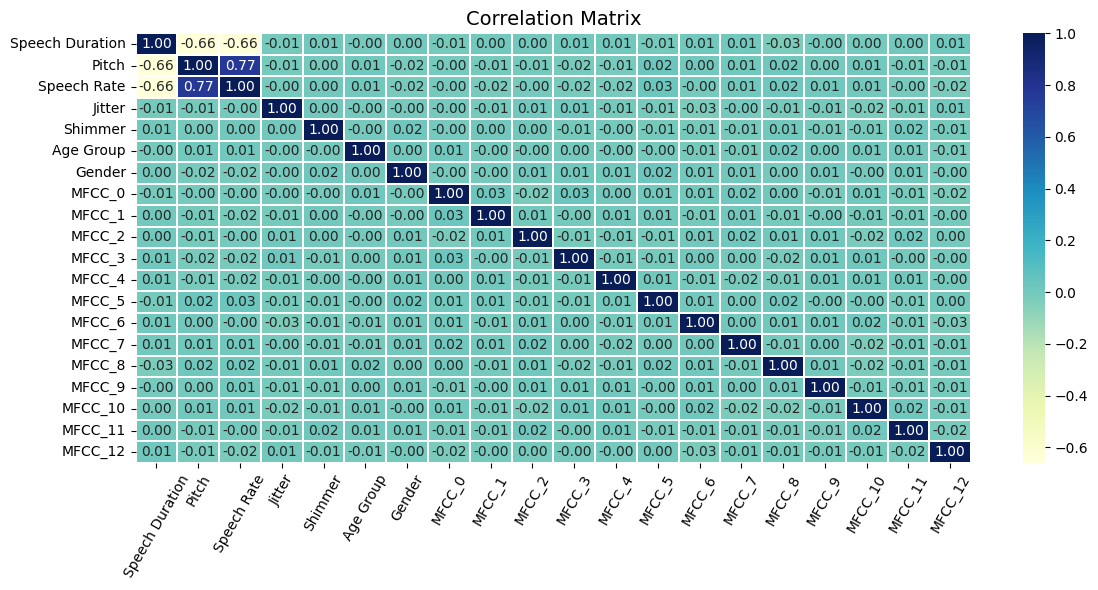

In [681]:
# Select numeric col values
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

# Correlation matrix
corrmat = data[numeric_cols].corr()

# Plot
f, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(corrmat,
            annot=True,
            fmt='.2f',
            ax=ax,
            cmap="YlGnBu",
            linewidths=0.1)
plt.title('Correlation Matrix', fontsize=14)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

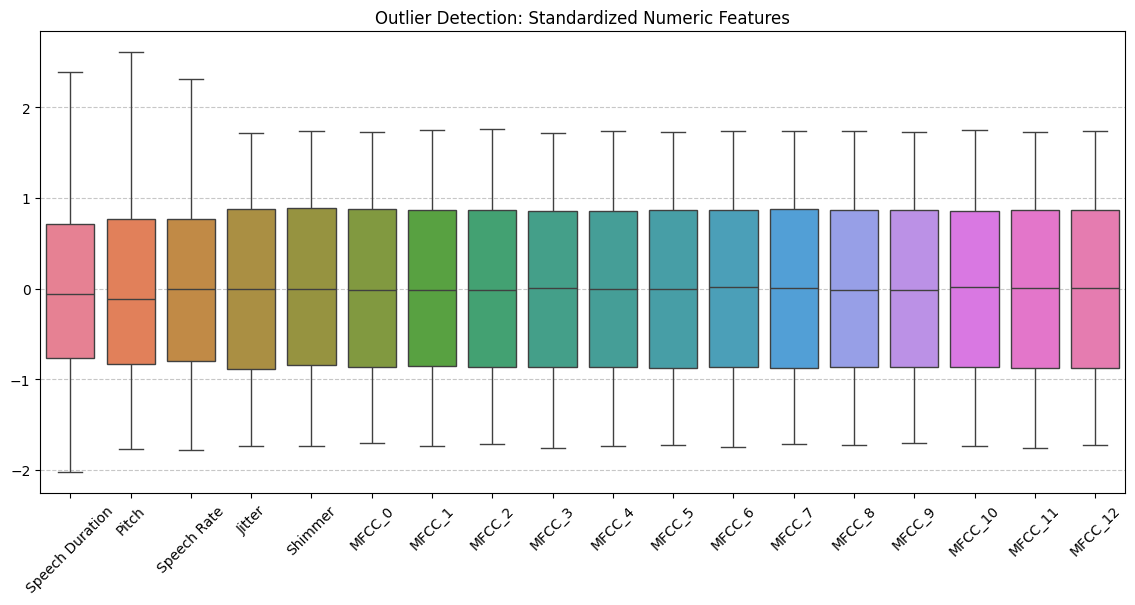

In [682]:
outlier_cols = [c for c in data.columns
                if c not in ('Mood', 'Gender', 'Age Group')]

standard_data = data.copy()
scaler = StandardScaler()
standard_data[outlier_cols] = scaler.fit_transform(data[outlier_cols])

plt.figure(figsize=(14, 6))
sns.boxplot(data=standard_data[outlier_cols])
plt.title('Outlier Detection: Standardized Numeric Features')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Ending data preparation


In [ ]:
if data['Mood'].dtype != int:
    le = LabelEncoder()
    data['Mood'] = le.fit_transform(data['Mood'])
    mood_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Mappatura Emozioni-Numeri:\n", mood_mapping, "\n")

pr_ft_np = data.columns.values
pr_ft = list(pr_ft_np)
pr_ft

if 'Mood' in pr_ft:
    pr_ft.remove('Mood')
    print('Mood correctly removed')
else:
    print("There's no 'Mood' feature in the dataset")

print("Is 'Mood' present in the final dataset?", 'Mood' in pr_ft)

yp = data[['Mood']].copy()


data.drop(columns=["Mood"], inplace=True)
Xp = data[pr_ft].copy()

Xp.shape

Mappatura Emozioni-Numeri:
 {'Angry': np.int64(0), 'Bored': np.int64(1), 'Calm': np.int64(2), 'Confused': np.int64(3), 'Excited': np.int64(4), 'Fearful': np.int64(5), 'Happy': np.int64(6), 'Neutral': np.int64(7), 'Sad': np.int64(8), 'Surprised': np.int64(9)} 

Mood correctly removed
Is 'Mood' present in the final dataset? False


(10000, 20)

### Splitting Dataset

In [662]:
X_train, X_test, y_train, y_test = train_test_split(Xp,
                                                    yp,
                                                    random_state=0,
                                                    test_size=0.2,
                                                    stratify=yp)

print(f'TRAIN TEST SPLIT DIM:')
print(f'X_train = {X_train.shape} || X_test = {X_test.shape}')
print(f'y_train = {y_train.shape} || y_test = {y_test.shape}')

TRAIN TEST SPLIT DIM:
X_train = (8000, 20) || X_test = (2000, 20)
y_train = (8000, 1) || y_test = (2000, 1)


## Feature selection (mutual information)

We reduce the feature set to the columns that actually carry information about `Mood`.

**Mutual information (MI)** measures how much knowing a feature reduces the uncertainty on
the target. Unlike linear correlation it also captures **non-linear** dependencies. It is
always ≥ 0: a value of 0 means feature and target are independent, larger values mean a
stronger dependency.

MI is computed on the **training set only** — using the test set here would leak information
about the data we evaluate on later. We then keep the features with MI > 0.05 and discard the
rest: most MFCC coefficients, `Jitter` and `Shimmer` score ≈ 0 and only add noise. This noise
is exactly what dragged KNN down, since irrelevant dimensions distort the distances it relies on.

`Sentiment Score` is dropped on purpose. It is derived from the *content* of the speech, not
from its acoustic signal, and it is so tightly tied to the emotion that it behaves as a
near-leakage shortcut. Since the task is to recognise emotion from the **acoustic** signature,
keeping it would defeat the purpose of the project.

,Importance
Pitch,1.212403
Speech Rate,1.184163
Speech Duration,0.718324
MFCC_6,0.016777
MFCC_7,0.006286


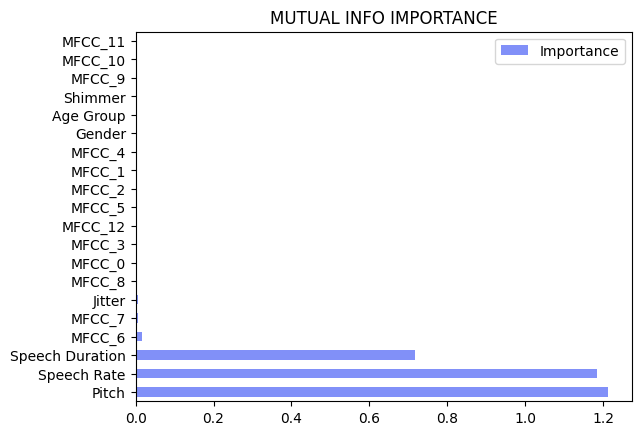

In [663]:
importance = mutual_info_classif(X_train, y_train.values.ravel())

ft_import = pd.DataFrame(data=importance, columns=['Importance'])

ft_import.set_index(X_train.columns, inplace=True)  

ft_import.sort_values('Importance',
                    ascending = False,
                    inplace = True)

ft_import.plot(kind='barh', color='#8190f8')
plt.title('MUTUAL INFO IMPORTANCE')
ft_import.head()

In [664]:
# Take only top-k feature per mutual info (ft_import)
selected = ft_import[ft_import['Importance'] > 0.05].index.tolist()

X_train = X_train[selected]
X_test  = X_test[selected]
print('Feature tenute:', selected)

Feature tenute: ['Pitch', 'Speech Rate', 'Speech Duration']


## Model training and validation

We train five classifiers from the assignment list: **Logistic Regression**, **Naïve Bayes**,
**KNN**, **Decision Tree** and a single-hidden-layer **MLP**.

Each model runs inside a pipeline that applies, in order:
1. **RandomUnderSampler**: balances the classes on the *training* folds only, leaving the
   test set untouched and realistic;
2. **StandardScaler**: puts all features on the same scale, essential for distance- and
   gradient-based models (KNN, Logistic Regression, MLP);
3. the **classifier** itself.

Performance is measured on the 20% holdout test set with three metrics:
- **Accuracy**: overall fraction of correct predictions;
- **weighted F1**: harmonic mean of precision and recall, weighted by class support (robust
  for the multiclass case);
- **weighted ROC AUC** (one-vs-one): ranking quality, averaged over all class pairs.

In [665]:
simplefilter("ignore", category=ConvergenceWarning)

# Definition models
models = {
    'LogisticRegression': LogisticRegression(random_state=42), 
    'NaiveBayes': GaussianNB(), 
    'KNN': KNeighborsClassifier(), 
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'MLP': MLPClassifier(random_state=42, max_iter=300) 
}

models_names = []
test_scores = []
f1_sc = []
roc = []
conf_matrs = []

for name in models:
    model = models[name]
    
    # Pipeline
    pipeline = Pipeline([
        ('undersampler', RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    
    # Training
    pipeline.fit(X_train, y_train.values.ravel())
    
    # Prevision
    y_pred_ts = pipeline.predict(X_test)
    y_proba_ts = pipeline.predict_proba(X_test) 
    
    # Metrics Evaluation
    test_score = pipeline.score(X_test, y_test.values.ravel())
    f1 = f1_score(y_test.values.ravel(), y_pred_ts, average='weighted')
    roc_auc = roc_auc_score(y_test.values.ravel(), y_proba_ts, multi_class='ovo', average='weighted')

    c_m = confusion_matrix(y_test, y_pred_ts)
    
    # Save
    models_names.append(name)
    test_scores.append(test_score)
    f1_sc.append(f1)
    roc.append(roc_auc)
    conf_matrs.append(c_m)

# Table with results
class_scores = pd.DataFrame(
    np.column_stack([test_scores, f1_sc, roc]),
    columns=['Test_Accuracy', 'F1_Score', 'ROC_AUC'],
    index=models_names
)

class_scores

,Test_Accuracy,F1_Score,ROC_AUC
LogisticRegression,0.6965,0.696562,0.971747
NaiveBayes,0.7085,0.709823,0.973177
KNN,0.6840,0.683889,0.954445
DecisionTree,0.7055,0.705423,0.836182
MLP,0.7280,0.728434,0.977829


## Evaluation

We compare the models across the three metrics, inspect each **confusion matrix** to see
*which* emotions get confused with one another (the off-diagonal cells), and finally pick the
best model by **ROC AUC** — the metric least sensitive to any residual class imbalance.

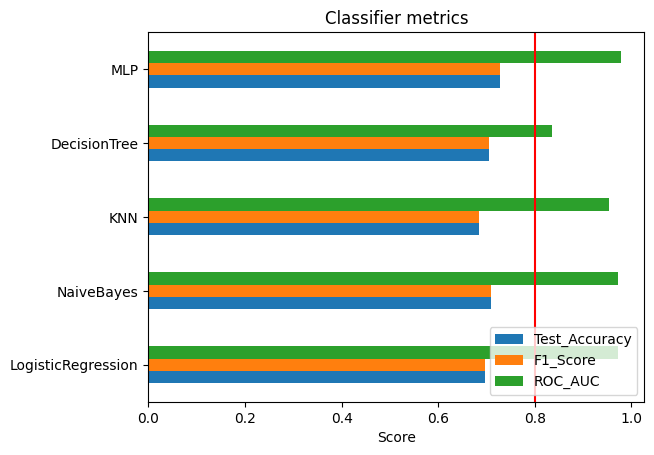

In [666]:
class_scores.plot(kind='barh')
plt.axvline(0.8, color='r')
plt.title('Classifier metrics')
plt.xlabel('Score')
plt.show()

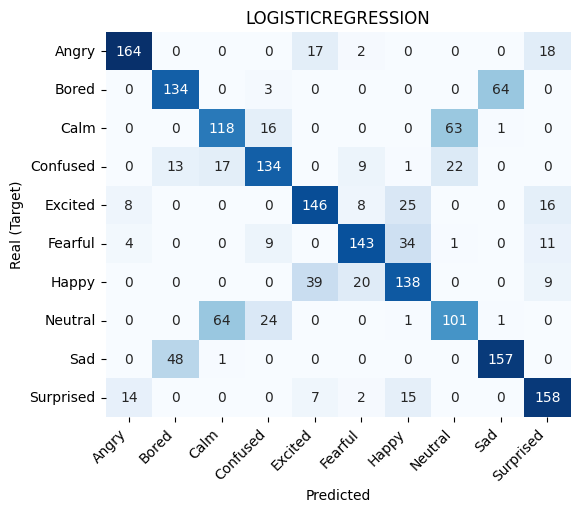

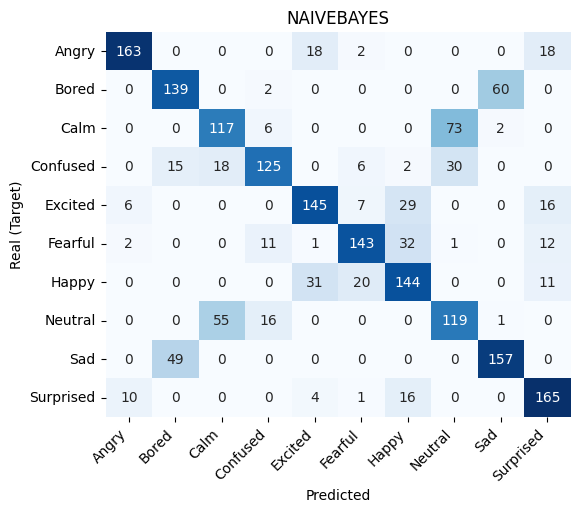

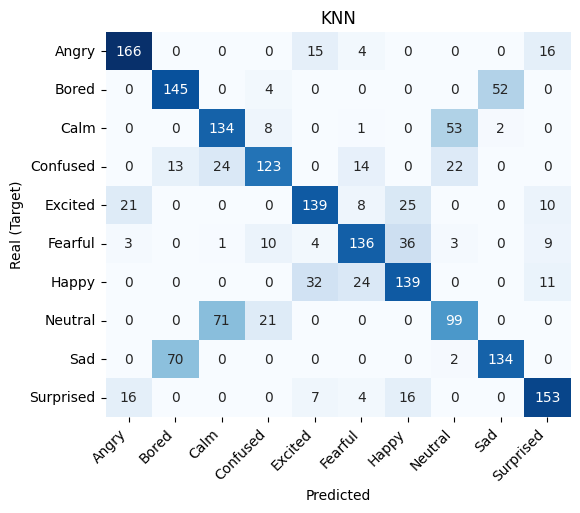

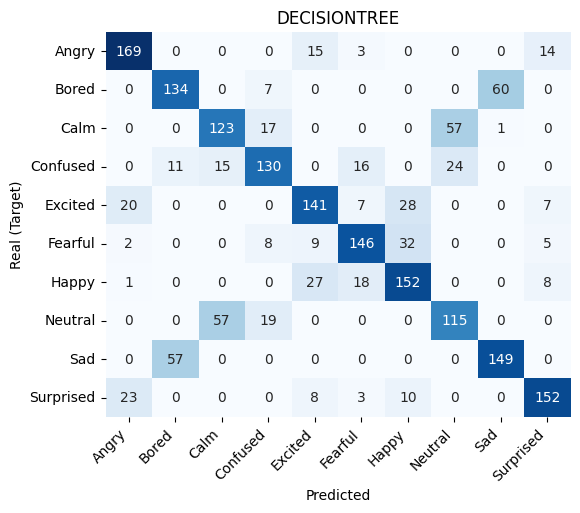

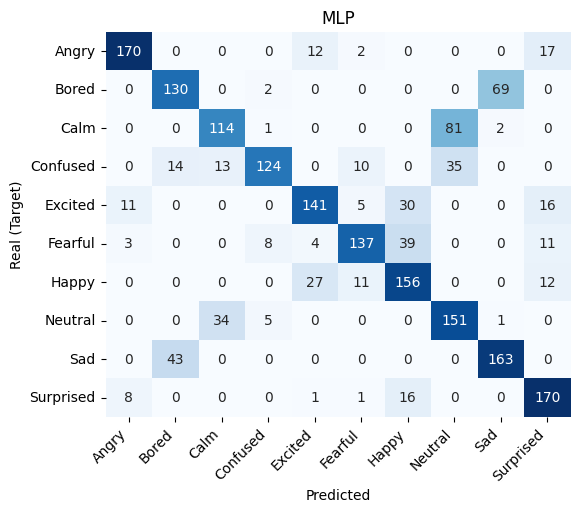

In [ ]:
for i, cm in enumerate(conf_matrs):
    plt.figure(figsize=(5, 5))
    plt.title(models_names[i].upper())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.ylabel('Real (Target)')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

In [668]:
score_chose = class_scores["ROC_AUC"].max()

mod = class_scores.loc[class_scores['ROC_AUC'] == score_chose].index[0]
mod

'MLP'

In [669]:
# Generating .arff file for WEKA
dataset_weka = pd.concat([Xp[selected], yp], axis=1)
file_name = "../weka-files/dataset_esame.arff"
target_col = "Mood"

dataset_weka[target_col] = dataset_weka[target_col].astype(int)

with open(file_name, "w") as f:
    f.write("@RELATION mood_classification\n\n")
    for col in dataset_weka.columns:
        if col == target_col:
            classi = ",".join(str(c) for c in sorted(dataset_weka[col].dropna().unique()))
            f.write(f'@ATTRIBUTE "{col}" {{{classi}}}\n')
        else:
            f.write(f'@ATTRIBUTE "{col}" NUMERIC\n')
    f.write("\n@DATA\n")
    dataset_weka.fillna('?').to_csv(f, header=False, index=False)

print(f"File '{file_name}' generated. {len(dataset_weka.columns)} feature "
      f"(class = '{target_col}', last col).")

File '../weka-files/dataset_esame.arff' generated. 4 feature (class = 'Mood', last col).


## scikit-learn vs WEKA comparison

Same protocol as the notebook: **80/20 holdout + standardized features**.

Run the 5 classifiers in WEKA with `weka-files/run_weka.sh`, then paste the metrics into
`weka_results` below. Full WEKA recipe (filter, classifier mapping, which value to read for
each metric) is in the [README](../README.md).

In [670]:
# Sklearn Results
sklearn_scores = class_scores.copy()
sklearn_scores.columns = ['Test_Accuracy_sklearn', 'F1_Score_sklearn', 'ROC_AUC_sklearn']

# WEKA Results
# To insert different results run weka-files/run_weka.sh and paste values here
weka_results = {  # WEKA: holdout 80/20 + Standardize, selected features (run_weka.sh)
    'LogisticRegression': [0.7020, 0.702, 0.974],   # [Accuracy, F1, ROC_AUC]
    'NaiveBayes':         [0.7149, 0.716, 0.975],
    'KNN':                [0.8173, 0.818, 0.989],
    'DecisionTree':       [0.7740, 0.773, 0.981],
    'MLP':                [0.6953, 0.693, 0.971],
}
weka_scores = pd.DataFrame.from_dict(
    weka_results, orient='index',
    columns=['Test_Accuracy_weka', 'F1_Score_weka', 'ROC_AUC_weka']
).astype(float)

comparison = sklearn_scores.join(weka_scores)
comparison = comparison[[
    'Test_Accuracy_sklearn', 'Test_Accuracy_weka',
    'F1_Score_sklearn', 'F1_Score_weka',
    'ROC_AUC_sklearn', 'ROC_AUC_weka',
]]
comparison.round(3)

,Test_Accuracy_sklearn,Test_Accuracy_weka,F1_Score_sklearn,F1_Score_weka,ROC_AUC_sklearn,ROC_AUC_weka
LogisticRegression,0.696,0.702,0.697,0.702,0.972,0.974
NaiveBayes,0.708,0.715,0.710,0.716,0.973,0.975
KNN,0.684,0.817,0.684,0.818,0.954,0.989
DecisionTree,0.706,0.774,0.705,0.773,0.836,0.981
MLP,0.728,0.695,0.728,0.693,0.978,0.971


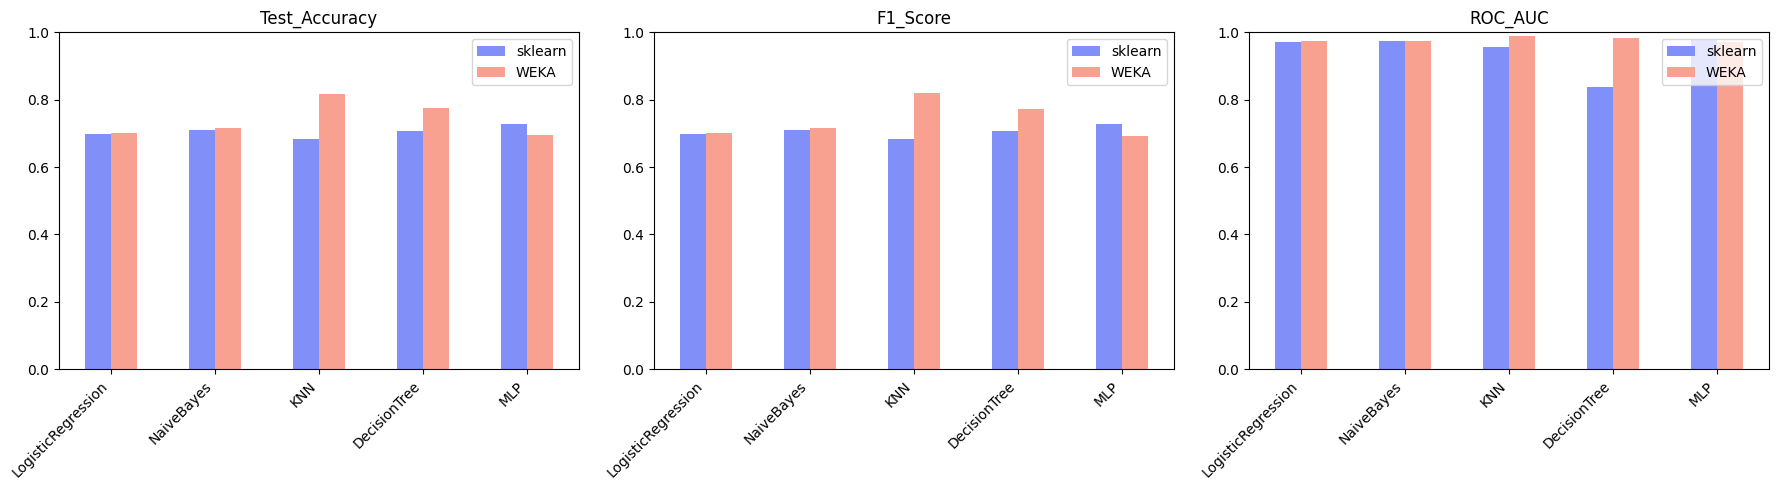

In [671]:
metrics = ['Test_Accuracy', 'F1_Score', 'ROC_AUC']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, metrics):
    sub = comparison[[f'{m}_sklearn', f'{m}_weka']]
    sub.plot(kind='bar', ax=ax, color=['#8190f8', '#f8a191'], legend=True)
    ax.set_title(m)
    ax.set_ylim(0, 1)
    ax.legend(['sklearn', 'WEKA'])
    ax.set_xticklabels(comparison.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()